# EEG Motor Imagery Classification Using Machine Learning

## D502 Data Analytics Capstone

### Research Question
Can a supervised machine learning model distinguish between left-hand and right-hand motor imagery using EEG signal data?

### Project Overview
This project uses EEG recordings from the PhysioNet EEG Motor Movement/Imagery Dataset. EEG signals from left-hand and right-hand motor imagery tasks are preprocessed and converted into features using Common Spatial Pattern (CSP). A Random Forest classifier is then trained to distinguish between the two motor imagery classes.

Model performance is evaluated using accuracy, precision, recall, F1 score, and a confusion matrix.

## 1. Environment Setup

The required Python libraries are imported for EEG processing, data manipulation, machine learning, and visualization. MNE-Python is used for EEG processing, while scikit-learn is used for model development and evaluation.

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import contextlib
import io

# EEG processing
import mne
from mne.datasets import eegbci
from mne.decoding import CSP

# Machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("MNE version:", mne.__version__)

MNE version: 1.13.2


## 2. Initial Dataset Inspection

A single subject is loaded first to verify the structure of the PhysioNet EEG data and confirm that the selected motor imagery runs contain the expected EEG channels, sampling frequency, and event annotations.

In [2]:
subject = 1
runs = [4, 8, 12]

files = eegbci.load_data(subject, runs)

files

C:\Users\xthef\OneDrive\Desktop\DA Capstone\Task 3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[WindowsPath('C:/Users/xthef/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf'),
 WindowsPath('C:/Users/xthef/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R08.edf'),
 WindowsPath('C:/Users/xthef/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R12.edf')]

In [3]:
raws = [
    mne.io.read_raw_edf(file, preload=True, verbose=False)
    for file in files
]

raw = mne.concatenate_raws(raws)

print(raw)
print("Channels:", len(raw.ch_names))
print("Sampling frequency:", raw.info["sfreq"])
print("Duration:", raw.times[-1], "seconds")
print("Annotations:")
print(raw.annotations)

<RawEDF | S001R04.edf, 64 x 60000 (375.0 s), ~29.3 MiB, data loaded>
Channels: 64
Sampling frequency: 160.0
Duration: 374.99375 seconds
Annotations:
<Annotations | 94 segments: BAD boundary (2), EDGE boundary (2), T0 (45), ...>


### Event Annotation Inspection

The EEG annotations are examined to identify the motor imagery events. For the selected runs, T1 and T2 represent the left-hand and right-hand motor imagery classes used in the analysis. Rest events (T0) are excluded from classification.

In [4]:
events, event_id = mne.events_from_annotations(raw)

print("Event IDs:")
print(event_id)

print("\nEvent counts:")
unique, counts = np.unique(events[:, 2], return_counts=True)

for event_code, count in zip(unique, counts):
    print(event_code, count)

Used Annotations descriptions: ['T0', 'T1', 'T2']
Event IDs:
{'T0': 1, 'T1': 2, 'T2': 3}

Event counts:
1 45
2 23
3 22


### Initial Preprocessing Test

The EEG signals are band-pass filtered from 8–30 Hz. The recordings are divided into 0–4 second epochs corresponding to the motor imagery events. This initial test verifies that the preprocessing procedure produces usable left-hand and right-hand trials before applying it to the full group of subjects.

In [5]:
# Keep only left-hand and right-hand motor imagery events
event_id = {
    "left_hand": 2,   # T1
    "right_hand": 3   # T2
}

# Filter EEG to the motor-imagery frequency range
raw_filtered = raw.copy().filter(
    l_freq=8.0,
    h_freq=30.0,
    fir_design="firwin",
    verbose=False
)

# Create 0–4 second epochs for each motor-imagery cue
epochs = mne.Epochs(
    raw_filtered,
    events,
    event_id=event_id,
    tmin=0.0,
    tmax=4.0,
    baseline=None,
    preload=True,
    reject_by_annotation=True,
    verbose=False
)

print("Left-hand trials:", len(epochs["left_hand"]))
print("Right-hand trials:", len(epochs["right_hand"]))
print("Epoch shape:", epochs.get_data().shape)

Left-hand trials: 23
Right-hand trials: 22
Epoch shape: (45, 64, 641)


## 3. Final Dataset Selection

Subjects 1–20 are selected for the final analysis. Runs 4, 8, and 12 are obtained for each subject because these recordings contain the left-hand and right-hand motor imagery tasks used in this project.

In [6]:
# Final subject group for the capstone
subjects = list(range(1, 21))
runs = [4, 8, 12]

subject_files = {}

for subject in subjects:
    subject_files[subject] = eegbci.load_data(
        subject,
        runs,
        update_path=False
    )

print("\nDownload complete.")
print("Subjects downloaded:", len(subject_files))
print(
    "Total EDF files:",
    sum(len(files) for files in subject_files.values())
)


Download complete.
Subjects downloaded: 20
Total EDF files: 60


## 4. EEG Preprocessing

The same preprocessing procedure is applied to each subject. The three motor imagery runs are combined, filtered from 8–30 Hz, and divided into 0–4 second epochs. Only left-hand and right-hand motor imagery events are retained.

Trial counts are recorded for each subject to assess data completeness and class balance.

In [7]:
all_epochs = {}
preprocessing_summary = []

for subject in subjects:
    # Load the three imagery runs
    raws = [
        mne.io.read_raw_edf(file, preload=True, verbose=False)
        for file in subject_files[subject]
    ]

    # Combine the three runs
    subject_raw = mne.concatenate_raws(raws)

    # Find annotation events
    subject_events, subject_event_id = mne.events_from_annotations(
        subject_raw,
        verbose=False
    )

    # Filter to 8–30 Hz
    subject_raw.filter(
        l_freq=8.0,
        h_freq=30.0,
        fir_design="firwin",
        verbose=False
    )

    # T1 = left hand, T2 = right hand
    imagery_event_id = {
        "left_hand": subject_event_id["T1"],
        "right_hand": subject_event_id["T2"]
    }

    # Create 0–4 second epochs
    subject_epochs = mne.Epochs(
        subject_raw,
        subject_events,
        event_id=imagery_event_id,
        tmin=0.0,
        tmax=4.0,
        baseline=None,
        preload=True,
        reject_by_annotation=True,
        verbose=False
    )

    all_epochs[subject] = subject_epochs

    left_count = len(subject_epochs["left_hand"])
    right_count = len(subject_epochs["right_hand"])

    preprocessing_summary.append({
        "subject": subject,
        "left_trials": left_count,
        "right_trials": right_count,
        "total_trials": left_count + right_count
    })

print("\nAll subjects processed.")

summary_df = pd.DataFrame(preprocessing_summary)

print(summary_df.to_string(index=False))

print("\nTotal usable trials:", summary_df["total_trials"].sum())
print("Total left-hand trials:", summary_df["left_trials"].sum())
print("Total right-hand trials:", summary_df["right_trials"].sum())


All subjects processed.
 subject  left_trials  right_trials  total_trials
       1           23            22            45
       2           23            22            45
       3           23            22            45
       4           23            22            45
       5           21            24            45
       6           24            21            45
       7           23            22            45
       8           22            23            45
       9           24            21            45
      10           24            21            45
      11           23            22            45
      12           21            24            45
      13           23            22            45
      14           22            23            45
      15           23            22            45
      16           22            23            45
      17           23            22            45
      18           22            23            45
      19           23    

## 5. Dataset Construction

The processed EEG epochs are combined into a single dataset. Each trial is assigned a class label and subject identifier.

- 0 = Left-hand motor imagery
- 1 = Right-hand motor imagery

Subject identifiers are retained so that training and testing can be separated by participant.

In [8]:
X_list = []
y_list = []
subject_id_list = []

for subject in subjects:
    subject_epochs = all_epochs[subject]

    X_subject = subject_epochs.get_data()

    y_subject = subject_epochs.events[:, 2]

    # Convert event codes to simple labels:
    # 0 = left hand
    # 1 = right hand
    y_subject = np.where(
        y_subject == subject_epochs.event_id["left_hand"],
        0,
        1
    )

    X_list.append(X_subject)
    y_list.append(y_subject)

    subject_id_list.extend(
        [subject] * len(subject_epochs)
    )

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
subject_ids = np.array(subject_id_list)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("subject_ids shape:", subject_ids.shape)

print("\nClass counts:")
print("Left hand:", np.sum(y == 0))
print("Right hand:", np.sum(y == 1))

print("\nUnique subjects:", np.unique(subject_ids))

X shape: (900, 64, 641)
y shape: (900,)
subject_ids shape: (900,)

Class counts:
Left hand: 455
Right hand: 445

Unique subjects: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


## 6. Training and Test Split

The dataset is divided into training and held-out test sets at the subject level. Subjects appearing in the test set are excluded from the training set.

This separation prevents EEG trials from the same participant from appearing in both sets and provides a stronger test of whether the model can classify motor imagery from previously unseen subjects.

In [9]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=subject_ids)
)

X_train = X[train_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

subjects_train = subject_ids[train_idx]
subjects_test = subject_ids[test_idx]

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining subjects:")
print(np.unique(subjects_train))

print("\nTest subjects:")
print(np.unique(subjects_test))

overlap = np.intersect1d(
    np.unique(subjects_train),
    np.unique(subjects_test)
)

print("\nSubject overlap:", overlap)

print("\nTraining class counts:")
print("Left:", np.sum(y_train == 0))
print("Right:", np.sum(y_train == 1))

print("\nTest class counts:")
print("Left:", np.sum(y_test == 0))
print("Right:", np.sum(y_test == 1))

Training shape: (720, 64, 641)
Test shape: (180, 64, 641)

Training subjects:
[ 3  4  5  6  7  8  9 10 11 12 13 14 15 17 19 20]

Test subjects:
[ 1  2 16 18]

Subject overlap: []

Training class counts:
Left: 365
Right: 355

Test class counts:
Left: 90
Right: 90


## 7. Common Spatial Pattern Feature Extraction

Common Spatial Pattern (CSP) is used to convert the multichannel EEG recordings into features for classification. Six CSP components are extracted.

CSP is fitted using only the training data. The fitted CSP transformation is then applied separately to the training and held-out test data to avoid information from the test subjects influencing feature extraction.

In [10]:
# Create CSP feature extractor
csp = CSP(
    n_components=6,
    reg=None,
    log=True,
    norm_trace=False
)

# Fit CSP using training data only
with contextlib.redirect_stdout(io.StringIO()):
    csp.fit(X_train, y_train)

print("CSP fitted successfully.")
print("Number of CSP components:", csp.n_components)

CSP fitted successfully.
Number of CSP components: 6


In [11]:
# Transform EEG trials into CSP features
X_train_csp = csp.transform(X_train)
X_test_csp = csp.transform(X_test)

# Verify feature dimensions and data quality
print("Training CSP shape:", X_train_csp.shape)
print("Test CSP shape:", X_test_csp.shape)

print("\nTraining contains NaN:", np.isnan(X_train_csp).any())
print("Test contains NaN:", np.isnan(X_test_csp).any())
print("Training contains infinity:", np.isinf(X_train_csp).any())
print("Test contains infinity:", np.isinf(X_test_csp).any())

Training CSP shape: (720, 6)
Test CSP shape: (180, 6)

Training contains NaN: False
Test contains NaN: False
Training contains infinity: False
Test contains infinity: False


## 8. Random Forest Classification

A Random Forest classifier with 200 decision trees is trained using the CSP features from the training subjects. Class weighting is balanced, and a fixed random state is used to make the analysis reproducible.

The trained model is then used to predict left-hand or right-hand motor imagery for the held-out subjects.

In [12]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train_csp, y_train)

y_pred = rf.predict(X_test_csp)

print("Random Forest trained successfully.")
print("Predictions generated:", len(y_pred))
print("Unique predicted classes:", np.unique(y_pred))

Random Forest trained successfully.
Predictions generated: 180
Unique predicted classes: [0 1]


## 9. Initial Model Evaluation

Model performance is evaluated on 180 trials from four held-out subjects. The test set contains 90 left-hand and 90 right-hand trials.

The evaluation includes:

- Accuracy
- Precision
- Recall
- F1 score
- Confusion matrix

The project established a practical performance target of at least 70% accuracy, with precision, recall, and F1 scores above 0.65 for each class.

In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Left Hand", "Right Hand"]
    )
)

Accuracy:  0.5444
Precision: 0.5450
Recall:    0.5444
F1 Score:  0.5430

Confusion Matrix:
[[54 36]
 [46 44]]

Classification Report:
              precision    recall  f1-score   support

   Left Hand       0.54      0.60      0.57        90
  Right Hand       0.55      0.49      0.52        90

    accuracy                           0.54       180
   macro avg       0.55      0.54      0.54       180
weighted avg       0.55      0.54      0.54       180



## 10. Comparison with Chance Baseline

The held-out test set contains an equal number of left-hand and right-hand motor imagery trials. A classifier guessing between the two balanced classes would therefore have an expected accuracy of 50%.

The Random Forest model's accuracy is compared with this baseline to measure how much classification performance exceeds chance.

In [14]:
chance_accuracy = 0.50

improvement_points = (accuracy - chance_accuracy) * 100
relative_improvement = (
    (accuracy - chance_accuracy) / chance_accuracy
) * 100

print(f"Chance baseline accuracy: {chance_accuracy:.2%}")
print(f"Model accuracy:           {accuracy:.2%}")
print(f"Difference:               {improvement_points:.2f} percentage points")
print(f"Relative improvement:     {relative_improvement:.2f}%")

Chance baseline accuracy: 50.00%
Model accuracy:           54.44%
Difference:               4.44 percentage points
Relative improvement:     8.89%


## 11. Subject-Level Cross-Validation

Group-based cross-validation is used to evaluate whether model performance is consistent across different groups of participants. Entire subjects are kept within a single fold so that EEG trials from one participant do not appear in both training and validation data.

For each fold, CSP is fitted only on the training subjects and then applied to the validation subjects. A new Random Forest classifier is also trained for each fold. This prevents information from the validation subjects from influencing feature extraction or model training.

In [15]:
group_cv = GroupKFold(n_splits=5)
cv_accuracies = []

for fold, (train_idx_cv, test_idx_cv) in enumerate(
    group_cv.split(X, y, groups=subject_ids), start=1
):
    X_train_cv = X[train_idx_cv]
    X_test_cv = X[test_idx_cv]

    y_train_cv = y[train_idx_cv]
    y_test_cv = y[test_idx_cv]

    test_subjects_cv = subject_ids[test_idx_cv]

    csp_cv = CSP(
        n_components=6,
        reg=None,
        log=True,
        norm_trace=False
    )

    # Suppress repeated CSP fitting messages
    with contextlib.redirect_stdout(io.StringIO()):
        X_train_csp_cv = csp_cv.fit_transform(
            X_train_cv,
            y_train_cv
        )

    X_test_csp_cv = csp_cv.transform(X_test_cv)

    rf_cv = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    )

    rf_cv.fit(X_train_csp_cv, y_train_cv)
    y_pred_cv = rf_cv.predict(X_test_csp_cv)

    fold_accuracy = accuracy_score(
        y_test_cv,
        y_pred_cv
    )

    cv_accuracies.append(fold_accuracy)

    print(
        f"Fold {fold}: "
        f"{fold_accuracy:.2%} accuracy | "
        f"Test subjects: {np.unique(test_subjects_cv)}"
    )

print("\nCross-validation results")
print("------------------------")
print(f"Mean accuracy: {np.mean(cv_accuracies):.2%}")
print(f"Standard deviation: {np.std(cv_accuracies):.2%}")
print(f"Minimum accuracy: {np.min(cv_accuracies):.2%}")
print(f"Maximum accuracy: {np.max(cv_accuracies):.2%}")

Fold 1: 54.44% accuracy | Test subjects: [ 5 10 15 20]
Fold 2: 52.78% accuracy | Test subjects: [ 4  9 14 19]
Fold 3: 52.78% accuracy | Test subjects: [ 3  8 13 18]
Fold 4: 57.78% accuracy | Test subjects: [ 2  7 12 17]
Fold 5: 48.33% accuracy | Test subjects: [ 1  6 11 16]

Cross-validation results
------------------------
Mean accuracy: 53.22%
Standard deviation: 3.05%
Minimum accuracy: 48.33%
Maximum accuracy: 57.78%


### Cross-Validation Results

Five-fold subject-level cross-validation produced a mean accuracy of 53.22%, with a standard deviation of 3.05%. Accuracy across the folds ranged from 48.33% to 57.78%.

These results are similar to the 54.44% accuracy obtained from the original held-out test set. The consistency between the held-out evaluation and cross-validation indicates that the model's performance on previously unseen subjects remained close to the 50% chance baseline across multiple subject groups.

The cross-validation results also remained below the project's predefined 70% accuracy target.

## 12. Data and Model Visualizations

### Class Distribution

The final dataset contains 900 motor imagery trials from 20 subjects. Class distribution is examined to determine whether a large class imbalance could affect model training or evaluation.

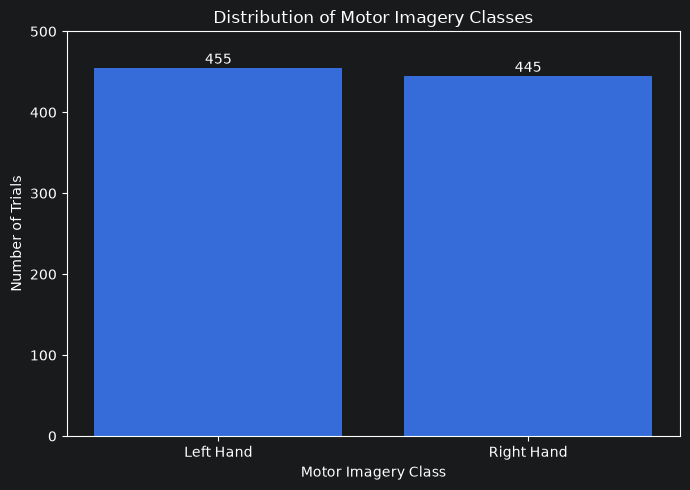

Left-hand trials: 455
Right-hand trials: 445
Difference: 10


In [16]:
# Class distribution visualization

class_names = ["Left Hand", "Right Hand"]
class_counts = [np.sum(y == 0), np.sum(y == 1)]

plt.figure(figsize=(7, 5))
bars = plt.bar(class_names, class_counts)

plt.title("Distribution of Motor Imagery Classes")
plt.xlabel("Motor Imagery Class")
plt.ylabel("Number of Trials")
plt.ylim(0, 500)

for bar, count in zip(bars, class_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(count),
        ha="center"
    )

plt.tight_layout()
plt.show()

print("Left-hand trials:", class_counts[0])
print("Right-hand trials:", class_counts[1])
print("Difference:", abs(class_counts[0] - class_counts[1]))

### EEG Signal Visualization

C3 and C4 are selected to visualize EEG activity during left-hand and right-hand motor imagery. The signals shown represent the average filtered EEG response across the motor imagery trials in the dataset. Comparing the averaged signals provides a visual representation of the variability and temporal patterns present in the EEG data.

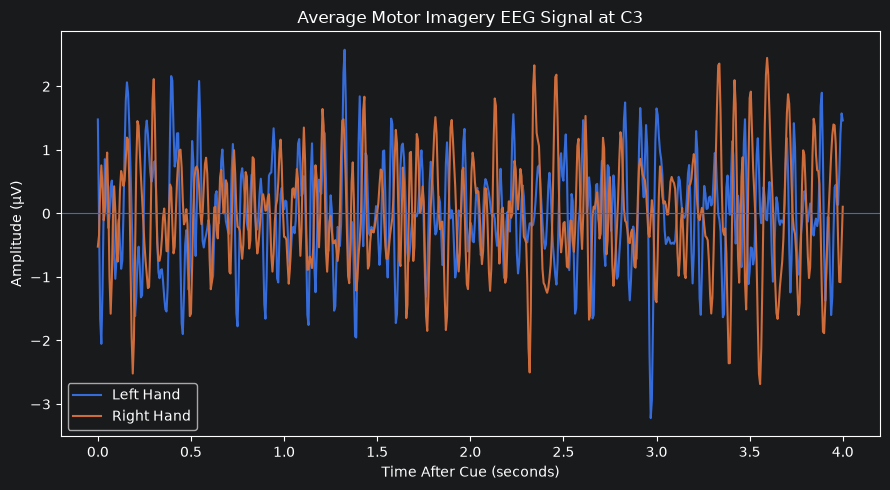

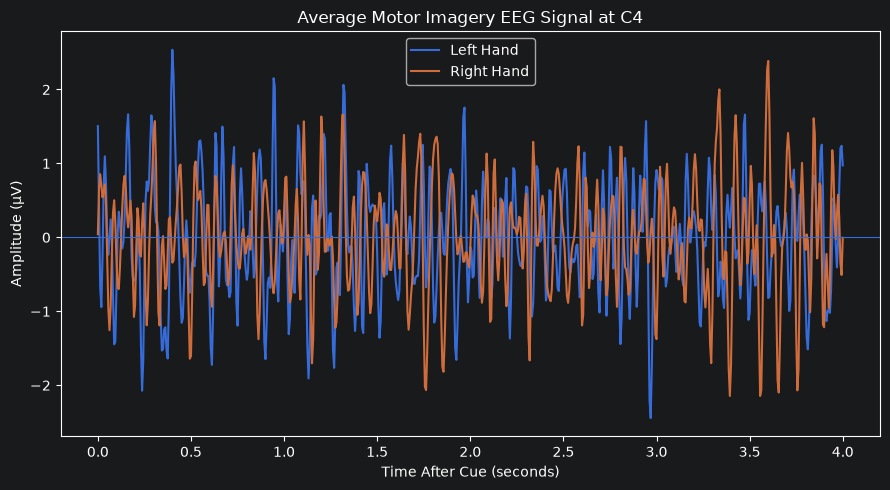

In [17]:
# Locate C3 and C4 channels
c3_idx = all_epochs[1].ch_names.index("C3..")
c4_idx = all_epochs[1].ch_names.index("C4..")

# Separate trials by class
left_trials = X[y == 0]
right_trials = X[y == 1]

# Average across trials and convert from volts to microvolts
left_c3 = left_trials[:, c3_idx, :].mean(axis=0) * 1e6
right_c3 = right_trials[:, c3_idx, :].mean(axis=0) * 1e6

left_c4 = left_trials[:, c4_idx, :].mean(axis=0) * 1e6
right_c4 = right_trials[:, c4_idx, :].mean(axis=0) * 1e6

# Time axis
times = all_epochs[1].times

# C3 visualization
plt.figure(figsize=(9, 5))

plt.plot(times, left_c3, label="Left Hand")
plt.plot(times, right_c3, label="Right Hand")

plt.axhline(0, linewidth=0.8)
plt.title("Average Motor Imagery EEG Signal at C3")
plt.xlabel("Time After Cue (seconds)")
plt.ylabel("Amplitude (µV)")
plt.legend()
plt.tight_layout()
plt.show()

# C4 visualization
plt.figure(figsize=(9, 5))

plt.plot(times, left_c4, label="Left Hand")
plt.plot(times, right_c4, label="Right Hand")

plt.axhline(0, linewidth=0.8)
plt.title("Average Motor Imagery EEG Signal at C4")
plt.xlabel("Time After Cue (seconds)")
plt.ylabel("Amplitude (µV)")
plt.legend()
plt.tight_layout()
plt.show()

### EEG Signal Visualization Results

The average EEG signals for left-hand and right-hand motor imagery show substantial overlap at both C3 and C4. Neither channel displays a consistent separation between the two classes across the four-second motor imagery period.

The overlapping average signals demonstrate the difficulty of separating the motor imagery classes from individual EEG channels based on their time-domain signals alone. This observation is consistent with the relatively low classification performance observed during model evaluation. CSP was used to extract spatial features across the full set of EEG channels rather than relying only on C3 or C4.

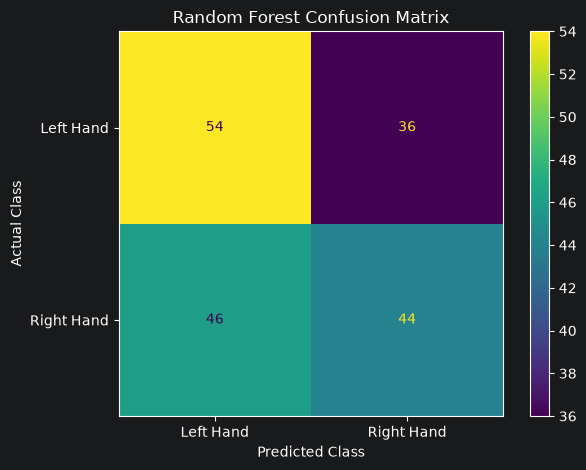

In [18]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Left Hand", "Right Hand"]
)

disp.plot(values_format="d")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

### Confusion Matrix Results

The model correctly classified 54 of 90 left-hand trials and 44 of 90 right-hand trials. It incorrectly classified 36 left-hand trials as right-hand and 46 right-hand trials as left-hand.

Errors occurred in both classes, which indicates that the model had difficulty separating left-hand and right-hand motor imagery rather than consistently favoring a single class.

### Model Performance

Accuracy, precision, recall, and F1 score are compared with the performance criteria established before model development. The project defined 70% accuracy and scores above 0.65 for precision, recall, and F1 as indicators of useful classification performance.

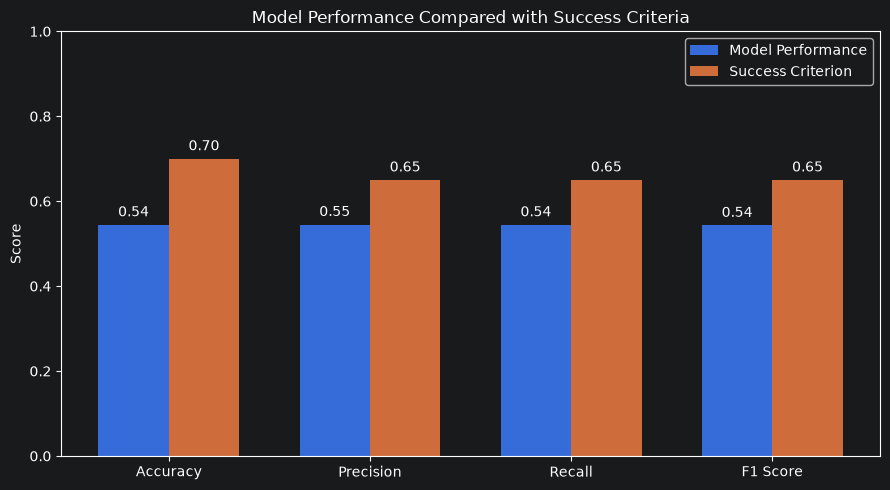

In [19]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

scores = [
    accuracy,
    precision,
    recall,
    f1
]

targets = [
    0.70,
    0.65,
    0.65,
    0.65
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

bars1 = plt.bar(
    x - width / 2,
    scores,
    width,
    label="Model Performance"
)

bars2 = plt.bar(
    x + width / 2,
    targets,
    width,
    label="Success Criterion"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Performance Compared with Success Criteria")
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{bar.get_height():.2f}",
            ha="center"
        )

plt.tight_layout()
plt.show()

### Model Performance Results

The model did not meet any of the predefined performance criteria. Accuracy was 54.44% compared with the 70% target. Macro precision was 54.50%, macro recall was 54.44%, and the macro F1 score was 54.30%, each below the 0.65 target.

The results indicate that the CSP and Random Forest approach did not provide sufficient classification performance for the predefined practical use criterion when applied to previously unseen subjects.

## 13. Interpretation of Classification Errors

The held-out test set contained 90 trials from each motor imagery class. The model correctly classified 54 left-hand trials and incorrectly classified 36 as right-hand trials, producing a left-hand recall of 60%. For right-hand imagery, 44 trials were correctly classified and 46 were incorrectly classified as left-hand, producing a right-hand recall of 49%.

The errors were distributed across both classes rather than being concentrated in one class. The balanced test set and similar error rates indicate that class imbalance was not the primary source of poor performance. The model showed slightly better recognition of left-hand imagery, but neither class achieved the predefined performance criteria.

Subject-level cross-validation also produced a mean accuracy of 53.22%, supporting the finding that classification remained difficult when the model was applied to previously unseen subjects.

## 14. Hypothesis Evaluation

The project hypothesis proposed that features extracted from EEG signals could be used by a supervised machine learning model to distinguish between left-hand and right-hand motor imagery with useful classification performance.

The results did not support this hypothesis under the conditions tested. The Random Forest classifier achieved 54.44% accuracy on the held-out test set and 53.22% mean accuracy during subject-level cross-validation. These results were only slightly above the 50% chance baseline and remained below the predefined 70% accuracy criterion.

The findings apply specifically to the preprocessing, CSP feature extraction, Random Forest model, selected subjects, and subject-independent evaluation used in this project. They do not establish that EEG motor imagery cannot be classified using other analytical approaches.